## READ ME:
**THE GOAL:** Predicting Credit Card defaults

**The "Why":** Comparing a linear baseline vs non-linear MLP

**Key Result:** MLP captured non-linearities better than the baseline model

# Deep Neural Networks (DNN)
## Comparing Linear Models and MLPs
**Dataset:** Default of Credit Card Clients (UCI ML Repository)  
**Goal:** Binary Classification

## Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time


# Allowed sklearn imports only
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

print("All libraries imported successfully.")

All libraries imported successfully.


## Step-1 : Dataset Selection

In [ ]:
# Load Dataset
# 24 Features (Excluding Target) & 30,000 Records - Fit the requirement , Since I am working into JPMC, choosing Banking dataset can be more relevant
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"

df = pd.read_excel(url, header=1)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
# Check class imbalance
class_distribution = df['default payment next month'].value_counts(normalize=True)
print(class_distribution)

default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


## The dataset is imbalanced, hence F1-score is used as the primary evaluation metric.

In [ ]:
# Dataset Description
print("=" * 60)
print("DATASET: Default of Credit Card Clients (UCI)")
print("=" * 60)
print(f"\nTotal Samples  : {df.shape[0]}")
print(f"Total Features : {df.shape[1] - 1} (excluding target)")
print(f"\nTask           : Binary Classification")
print(f"Target Column  : 'default payment next month'")
print(f"  0 = No Default (Non-Fraud / Safe Client)")
print(f"  1 = Default    (Potential Fraud / Risky Client)")
print(f"\nPrimary Metric : F1-Score (Macro)")
print(f"  Justification: The dataset is imbalanced (~22% defaults).")
print(f"  In fraud detection, both False Positives (blocking legit")
print(f"  customers) and False Negatives (missing fraud) are costly.")
print(f"  F1-Score balances Precision and Recall, making it the most")
print(f"  appropriate metric for this imbalanced fraud-related task.")
print()

print("\nFeature Descriptions:")
features_desc = {
    "LIMIT_BAL": "Credit limit (NT dollar)",
    "SEX": "Gender (1=Male, 2=Female)",
    "EDUCATION": "Education level (1=grad, 2=university, 3=high school, 4=others)",
    "MARRIAGE": "Marital status (1=married, 2=single, 3=others)",
    "AGE": "Age in years",
    "PAY_0–PAY_6": "Repayment status (Apr–Sep 2005)",
    "BILL_AMT1–6": "Bill statement amount (Apr–Sep 2005)",
    "PAY_AMT1–6": "Previous payment amount (Apr–Sep 2005)"
}
for k, v in features_desc.items():
    print(f"  {k:<20} : {v}")

print("\nClass Distribution:")
print(df['default payment next month'].value_counts())
print(f"\nDefault Rate: {df['default payment next month'].mean()*100:.2f}%")

DATASET: Default of Credit Card Clients (UCI)

Total Samples  : 30000
Total Features : 24 (excluding target)

Task           : Binary Classification
Target Column  : 'default payment next month'
  0 = No Default (Non-Fraud / Safe Client)
  1 = Default    (Potential Fraud / Risky Client)

Primary Metric : F1-Score (Macro)
  Justification: The dataset is imbalanced (~22% defaults).
  In fraud detection, both False Positives (blocking legit
  customers) and False Negatives (missing fraud) are costly.
  F1-Score balances Precision and Recall, making it the most
  appropriate metric for this imbalanced fraud-related task.


Feature Descriptions:
  LIMIT_BAL            : Credit limit (NT dollar)
  SEX                  : Gender (1=Male, 2=Female)
  EDUCATION            : Education level (1=grad, 2=university, 3=high school, 4=others)
  MARRIAGE             : Marital status (1=married, 2=single, 3=others)
  AGE                  : Age in years
  PAY_0–PAY_6          : Repayment status (Apr–Sep 

In [ ]:
# Basic Info
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
df.describe()

ID                            int64
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

Missing Values:
ID                            0
LIMIT_BAL                     0
SEX  

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## Step-2 : Data Preprocessing

In [ ]:
# Rename and Drop ID
df.rename(columns={'default payment next month': 'target'}, inplace=True)
df.drop(columns=['ID'], inplace=True)

print("Columns after cleanup:", df.columns.tolist())

Columns after cleanup: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'target']


In [ ]:
# Handle Missing Values
print("Missing values per column:")
print(df.isnull().sum())
# No missing values in this dataset, but we can handle just in case
df.fillna(df.median(), inplace=True)
print("\nMissing values after imputation:", df.isnull().sum().sum())

Missing values per column:
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
target       0
dtype: int64

Missing values after imputation: 0


In [ ]:
# Data Quality Issues
# The UCI documentation only defines EDUCATION values 1–4, but the data has 0, 5, 6.
# EDUCATION: Mapping values 0, 5, 6 to 4 (others)
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# The UCI documentation only defines MARRIAGE values 1–3, but the data has 0.
# MARRIAGE: Mapping value 0 to 3 (others)
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

print("EDUCATION value counts:", df['EDUCATION'].value_counts().to_dict())
print("MARRIAGE value counts :", df['MARRIAGE'].value_counts().to_dict())

EDUCATION value counts: {2: 14030, 1: 10585, 3: 4917, 4: 468}
MARRIAGE value counts : {2: 15964, 1: 13659, 3: 377}


In [ ]:
# Feature / Target Split
X = df.drop(columns=['target']).values.astype(np.float64)  # X is a 2D NumPy array of all features
y = df['target'].values.astype(np.float64)      # y is a 1D array of 0s and 1s

feature_names = df.drop(columns=['target']).columns.tolist()
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")

X shape: (30000, 23)
y shape: (30000,)
Number of features: 23


In [ ]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)    # stratify=y ensures the default rate (~22%) is the same in both splits - Important for imbalanced data

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")
print(f"Train default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate : {y_test.mean()*100:.2f}%")

Train size : 24000 samples
Test size  : 6000 samples
Train default rate: 22.12%
Test default rate : 22.12%


In [ ]:
# Feature Scaling
# Converts features to mean=0, std=1. Critical for gradient descent to converge — without this, large features would dominate.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling (StandardScaler) applied.")
print(f"Train mean (post-scale): {X_train_scaled.mean():.4f}")
print(f"Train std  (post-scale): {X_train_scaled.std():.4f}")

Feature scaling (StandardScaler) applied.
Train mean (post-scale): 0.0000
Train std  (post-scale): 1.0000


/tmp/ipykernel_1851/2346783233.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


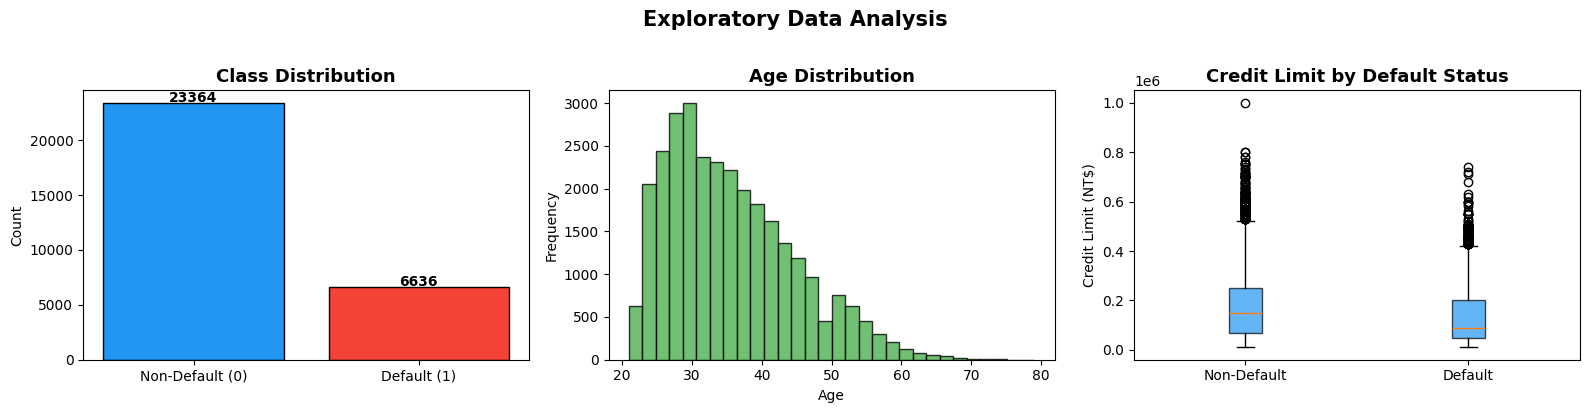

EDA plots saved.


In [ ]:
# Exploratory Data Analysis & Preprocessing Summary Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
axes[0].bar(['Non-Default (0)', 'Default (1)'],
            [np.sum(y==0), np.sum(y==1)],
            color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([np.sum(y==0), np.sum(y==1)]):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Age distribution
axes[1].hist(df['AGE'], bins=30, color='#4CAF50', edgecolor='black', alpha=0.8)
axes[1].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')

# Credit limit by default
axes[2].boxplot(
    [df[df['target']==0]['LIMIT_BAL'], df[df['target']==1]['LIMIT_BAL']],
    labels=['Non-Default', 'Default'],
    patch_artist=True,
    boxprops=dict(facecolor='#2196F3', alpha=0.7)
)
axes[2].set_title('Credit Limit by Default Status', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Credit Limit (NT$)')

plt.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_plot.png', dpi=120, bbox_inches='tight')
plt.show()
print("EDA plots saved.")

## Step-3 : Baseline Model – Logistic Regression from Scratch

In [ ]:
class LogisticRegression:

# Storering hyperparameters. Weights are initialized in
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations   = n_iterations
        self.weights        = None
        self.bias           = None
        self.loss_history   = []

# Converts any real number → probability between 0 and 1. The two-case formula is numerically stable — avoids overflow when z is very negative
# sigmoid(z) = 1 / (1 + e^(−z))

    def _sigmoid(self, z):
        """Numerically stable sigmoid."""
        return np.where(z >= 0,
                        1 / (1 + np.exp(-z)),
                        np.exp(z) / (1 + np.exp(z)))

#This is Binary Cross-Entropy. When prediction matches label, loss is near 0. When wrong, loss is high
    def _compute_loss(self, y_true, y_pred):
        """Binary cross-entropy loss."""
        eps = 1e-9  # Clips predictions to [0.000000001, 0.999999999]. Prevents log(0) = −∞
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def fit(self, X, y):
        """
        Training loop:
        1. Forward pass  → compute predictions
        2. Compute loss
        3. Compute gradients
        4. Update weights: w = w - lr * grad
        """
        n_samples, n_features = X.shape

        # Initialise weights and bias to zero
        self.weights = np.zeros(n_features)
        self.bias    = 0.0
        self.loss_history = []

        for i in range(self.n_iterations):
            # Forward pass
            z         = X @ self.weights + self.bias   # Linear combination : for each sample, multiply each feature by its weight and sum
            y_pred    = self._sigmoid(z)               # Convert to probability | Converts 24000 probabilities in [0,1]

            # Compute loss
            loss = self._compute_loss(y, y_pred)
            self.loss_history.append(loss)

            # Compute gradients
            error    = y_pred - y                      # Error for each sample | Error = Prediction - Actual
            dw       = (X.T @ error) / n_samples       # gradient w.r.t. weights | Gradient: how much each weight contributed to the error, averaged across all samples
            db       = np.mean(error)                  # gradient w.r.t. bias

            # Update weights: w = w - lr * grad
            self.weights -= self.learning_rate * dw
            self.bias    -= self.learning_rate * db

            if (i + 1) % 100 == 0:
                print(f"  Iteration {i+1:4d}/{self.n_iterations} | Loss: {loss:.6f}")

        return self

    def predict_proba(self, X):
        """Return predicted probabilities."""
        z = X @ self.weights + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        """Return binary predictions (0 or 1)."""
        return (self.predict_proba(X) >= threshold).astype(int)


print("LogisticRegression class defined.")

LogisticRegression class defined.


In [ ]:
# Training Model
print("Training Logistic Regression (from scratch)...")
print("-" * 50)

baseline_model = LogisticRegression(learning_rate=0.1, n_iterations=1000)

start_time = time.time()
baseline_model.fit(X_train_scaled, y_train)
baseline_train_time = time.time() - start_time

print(f"\nTraining completed in {baseline_train_time:.4f} seconds")

Training Logistic Regression (from scratch)...
--------------------------------------------------
  Iteration  100/1000 | Loss: 0.472664
  Iteration  200/1000 | Loss: 0.464828
  Iteration  300/1000 | Loss: 0.463763
  Iteration  400/1000 | Loss: 0.463507
  Iteration  500/1000 | Loss: 0.463416
  Iteration  600/1000 | Loss: 0.463373
  Iteration  700/1000 | Loss: 0.463348
  Iteration  800/1000 | Loss: 0.463331
  Iteration  900/1000 | Loss: 0.463318
  Iteration 1000/1000 | Loss: 0.463309

Training completed in 6.2198 seconds


In [ ]:
# Evaluate Baseline
y_pred_baseline  = baseline_model.predict(X_test_scaled)  # Predit 0 or 1
y_proba_baseline = baseline_model.predict_proba(X_test_scaled)  #Predict Probabilities 0.0 – 1.0

baseline_metrics = {
    'accuracy' : accuracy_score(y_test, y_pred_baseline),
    'precision': precision_score(y_test, y_pred_baseline, average='macro', zero_division=0),
    'recall'   : recall_score(y_test, y_pred_baseline, average='macro', zero_division=0),
    'f1'       : f1_score(y_test, y_pred_baseline, average='macro', zero_division=0),
    'roc_auc'  : roc_auc_score(y_test, y_proba_baseline)
}

print("\n" + "=" * 50)
print("BASELINE MODEL (Logistic Regression) — TEST METRICS")
print("=" * 50)
for k, v in baseline_metrics.items():
    print(f"  {k:<12}: {v:.4f}")
print(f"  {'train_time':<12}: {baseline_train_time:.4f}s")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['Non-Default','Default']))


BASELINE MODEL (Logistic Regression) — TEST METRICS
  accuracy    : 0.8078
  precision   : 0.7524
  recall      : 0.6050
  f1          : 0.6220
  roc_auc     : 0.7069
  train_time  : 6.2198s

Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.82      0.97      0.89      4673
     Default       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



## Step - 4: Neural Network: Multi-Layer Perceptron

In [ ]:
class MLP:
    """
    Multi-Layer Perceptron (MLP)

    Architecture: [input, hidden layer1, hidden layer2, ..., output]
    - Hidden layers : ReLU activation
    - Output layer  : Sigmoid activation (binary classification)
    - Loss          : Binary Cross-Entropy
    - Optimiser     : Gradient Descent
    """

    def __init__(self, layer_sizes, learning_rate=0.01, n_iterations=1000):
        """
        Initialise MLP architecture.
        Parameters
        ----------
        layer_sizes   : list of ints, e.g. [23, 64, 32, 1]
        - input: 23 features
        - hidden1: 64 neurons
        - hidden2: 32 neurons
        - output: 1 neuron (for binary classification)
        """
        self.layer_sizes    = layer_sizes   # [23, 64, 32, 1]
        self.learning_rate  = learning_rate  # 0.01
        self.n_iterations   = n_iterations  # 1000
        self.parameters     = {}            # will hold W1,b1,W2,b2,W3,b3
        self.loss_history   = []            # fills during training
        self.initialize_parameters()

    # ─────────────────────────────────────────────────────────────────────────
    def initialize_parameters(self):

        #Initialize W and b for each layer
        #suitable for ReLU activations

        np.random.seed(42)
        n_layers = len(self.layer_sizes)

        for l in range(1, n_layers):            # l = 1, 2, 3
            fan_in = self.layer_sizes[l - 1]    # input size for this layer

            self.parameters[f'W{l}'] = (
                np.random.randn(self.layer_sizes[l - 1], self.layer_sizes[l])
                * np.sqrt(2.0 / fan_in)          # He initialisation
            )
            self.parameters[f'b{l}'] = np.zeros((1, self.layer_sizes[l]))

        print(f"Parameters initialised for architecture: {self.layer_sizes}")
        for l in range(1, len(self.layer_sizes)):
            print(f"  Layer {l}: W{l} {self.parameters[f'W{l}'].shape}  "
                  f"b{l} {self.parameters[f'b{l}'].shape}")

    # ─────────────────────────────────────────────────────────────────────────
    @staticmethod
    def _relu(z):                 # if z<0 → 0, else → z
        return np.maximum(0, z)   # ReLU activation: max(0, z)

    @staticmethod
    def _relu_derivative(z):            # 1 if z>0, else 0
        return (z > 0).astype(float)    # derivative of ReLU

    @staticmethod
    def _sigmoid(z):                    # sigmoid for output layer
        return np.where(z >= 0,
                        1 / (1 + np.exp(-z)),
                        np.exp(z) / (1 + np.exp(z)))

    @staticmethod
    def _compute_loss(y_true, y_pred):
        eps = 1e-9
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    # ─────────────────────────────────────────────────────────────────────────
    def forward_propagation(self, X):

        #Compute activations through all layers

        cache   = {'A0': X}            # store input as layer 0 activation
        n_layers = len(self.layer_sizes) - 1
        A        = X

        for l in range(1, n_layers + 1):    # l = 1, 2, 3
            #Z = A @ W[l] + b[l]
            Z = A @ self.parameters[f'W{l}'] + self.parameters[f'b{l}']   # linear step
            cache[f'Z{l}'] = Z          # SAVE Z for backprop later

            if l < n_layers:          # Hidden layers → ReLU
                A = self._relu(Z)
            else:                     # Output layer  → Sigmoid
                A = self._sigmoid(Z)

            cache[f'A{l}'] = A        # SAVE A for backprop later

        return cache

    # ─────────────────────────────────────────────────────────────────────────
    def backward_propagation(self, cache, y):
        """
        Compute gradients using the chain rule.

        Returns
        -------
        gradients : dict with dW and db for each layer
        """
        gradients = {}
        n_samples  = y.shape[0]
        n_layers   = len(self.layer_sizes) - 1

        # Output layer gradient (sigmoid + BCE combined)
        AL      = cache[f'A{n_layers}']          # # final predictions (n, 1)
        y_col   = y.reshape(-1, 1)
        dA      = AL - y_col                     # dL/dA for output error gradient

        # Backprop through layers (from output → input)
        for l in reversed(range(1, n_layers + 1)):    # 3, 2, 1
            A_prev = cache[f'A{l-1}']            # activation from previous layer
            Z      = cache[f'Z{l}']              # pre-activation from this layer

            if l == n_layers:                    # output layer: sigmoid derivative = A*(1-A)
                dZ = dA
            else:                                # hidden layers: multiply by ReLU derivative
                dZ = dA * self._relu_derivative(Z)

            gradients[f'dW{l}'] = (A_prev.T @ dZ) / n_samples
            gradients[f'db{l}'] = np.mean(dZ, axis=0, keepdims=True)

            # Propagate gradient to previous layer
            dA = dZ @ self.parameters[f'W{l}'].T      # pass gradient back

        return gradients

    # ─────────────────────────────────────────────────────────────────────────
    def fit(self, X, y):

        #Training loop with forward and backward passes.
        self.loss_history = []

        for i in range(self.n_iterations):
            # Forward propagation : get all activations
            cache = self.forward_propagation(X)

            # Extract final output and Compute loss
            n_layers = len(self.layer_sizes) - 1
            y_pred   = cache[f'A{n_layers}'].flatten()
            loss     = self._compute_loss(y, y_pred)
            self.loss_history.append(loss)

            # Backward propagation : get all gradients
            gradients = self.backward_propagation(cache, y)

            # Update weights: w = w - lr * grad
            for l in range(1, n_layers + 1):
                self.parameters[f'W{l}'] -= self.learning_rate * gradients[f'dW{l}']
                self.parameters[f'b{l}'] -= self.learning_rate * gradients[f'db{l}']

            if (i + 1) % 100 == 0:
                print(f"  Epoch {i+1:4d}/{self.n_iterations} | Loss: {loss:.6f}")

        return self

    # ─────────────────────────────────────────────────────────────────────────
    def predict_proba(self, X):
        # Return predicted probabilities
        cache    = self.forward_propagation(X)    # forward only
        n_layers = len(self.layer_sizes) - 1
        return cache[f'A{n_layers}'].flatten()    # probabilities

    def predict(self, X, threshold=0.5):
        # Return binary predictions
        return (self.predict_proba(X) >= threshold).astype(int)
         # prob >= 0.5 → 1 (Default)
         # prob <  0.5 → 0 (Non-Default)

print("MLP class defined")

MLP class defined


In [ ]:
# Train MLP
# Architecture: [input=23, hidden1=64, hidden2=32, output=1]
n_features = X_train_scaled.shape[1]        # 23
architecture = [n_features, 64, 32, 1]      # [23, 64, 32, 1]

print("Training MLP ...")
print(f"Architecture: {architecture}")
print("-" * 50)

"""
The MLP has many more parameters and non-linear activations —
a larger step can cause unstable, oscillating loss. 0.01 is
the safer default for deeper networks
"""
mlp_model = MLP(
    layer_sizes   = architecture,         # [23, 64, 32, 1]
    learning_rate = 0.01,                 # smaller than 0.1
    n_iterations  = 1000
)

start_time = time.time()
mlp_model.fit(X_train_scaled, y_train)
mlp_train_time = time.time() - start_time

print(f"\nTraining completed in {mlp_train_time:.4f} seconds")

Training MLP ...
Architecture: [23, 64, 32, 1]
--------------------------------------------------
Parameters initialised for architecture: [23, 64, 32, 1]
  Layer 1: W1 (23, 64)  b1 (1, 64)
  Layer 2: W2 (64, 32)  b2 (1, 32)
  Layer 3: W3 (32, 1)  b3 (1, 1)
  Epoch  100/1000 | Loss: 0.543638
  Epoch  200/1000 | Loss: 0.513434
  Epoch  300/1000 | Loss: 0.497830
  Epoch  400/1000 | Loss: 0.488387
  Epoch  500/1000 | Loss: 0.482144
  Epoch  600/1000 | Loss: 0.477651
  Epoch  700/1000 | Loss: 0.474294
  Epoch  800/1000 | Loss: 0.471599
  Epoch  900/1000 | Loss: 0.469347
  Epoch 1000/1000 | Loss: 0.467414

Training completed in 88.6081 seconds


In [ ]:
# Evaluate MLP
y_pred_mlp  = mlp_model.predict(X_test_scaled)
y_proba_mlp = mlp_model.predict_proba(X_test_scaled)

mlp_metrics = {
    'accuracy' : accuracy_score(y_test, y_pred_mlp),
    'precision': precision_score(y_test, y_pred_mlp, average='macro', zero_division=0),
    'recall'   : recall_score(y_test, y_pred_mlp, average='macro', zero_division=0),
    'f1'       : f1_score(y_test, y_pred_mlp, average='macro', zero_division=0),
    'roc_auc'  : roc_auc_score(y_test, y_proba_mlp)
}

print("\n" + "=" * 50)
print("MLP MODEL — TEST METRICS")
print("=" * 50)
for k, v in mlp_metrics.items():
    print(f"  {k:<12}: {v:.4f}")
print(f"  {'train_time':<12}: {mlp_train_time:.4f}s")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=['Non-Default','Default']))


MLP MODEL — TEST METRICS
  accuracy    : 0.8072
  precision   : 0.7366
  recall      : 0.6177
  f1          : 0.6375
  roc_auc     : 0.7050
  train_time  : 88.6081s

Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.82      0.96      0.89      4673
     Default       0.65      0.28      0.39      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.62      0.64      6000
weighted avg       0.79      0.81      0.78      6000



## Step - 5: Evaluation & Comparison

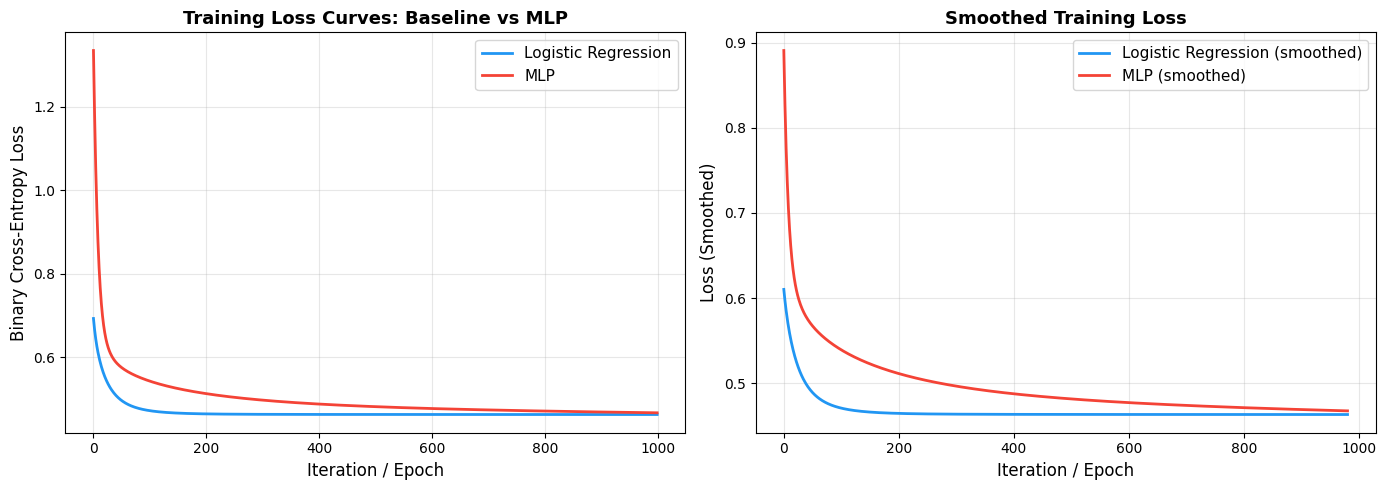

Loss curves saved


In [ ]:
# Plot 1: Training Loss Curves (Baseline vs MLP)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual loss curves
axes[0].plot(baseline_model.loss_history, color='#2196F3', linewidth=2, label='Logistic Regression')
axes[0].plot(mlp_model.loss_history,      color='#F44336', linewidth=2, label='MLP')
axes[0].set_xlabel('Iteration / Epoch', fontsize=12)
axes[0].set_ylabel('Binary Cross-Entropy Loss', fontsize=12)
axes[0].set_title('Training Loss Curves: Baseline vs MLP', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Smoothed (running average)
window = 20
bl_smooth  = np.convolve(baseline_model.loss_history, np.ones(window)/window, mode='valid')
mlp_smooth = np.convolve(mlp_model.loss_history,      np.ones(window)/window, mode='valid')
axes[1].plot(bl_smooth,  color='#2196F3', linewidth=2, label='Logistic Regression (smoothed)')
axes[1].plot(mlp_smooth, color='#F44336', linewidth=2, label='MLP (smoothed)')
axes[1].set_xlabel('Iteration / Epoch', fontsize=12)
axes[1].set_ylabel('Loss (Smoothed)', fontsize=12)
axes[1].set_title('Smoothed Training Loss', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("Loss curves saved")

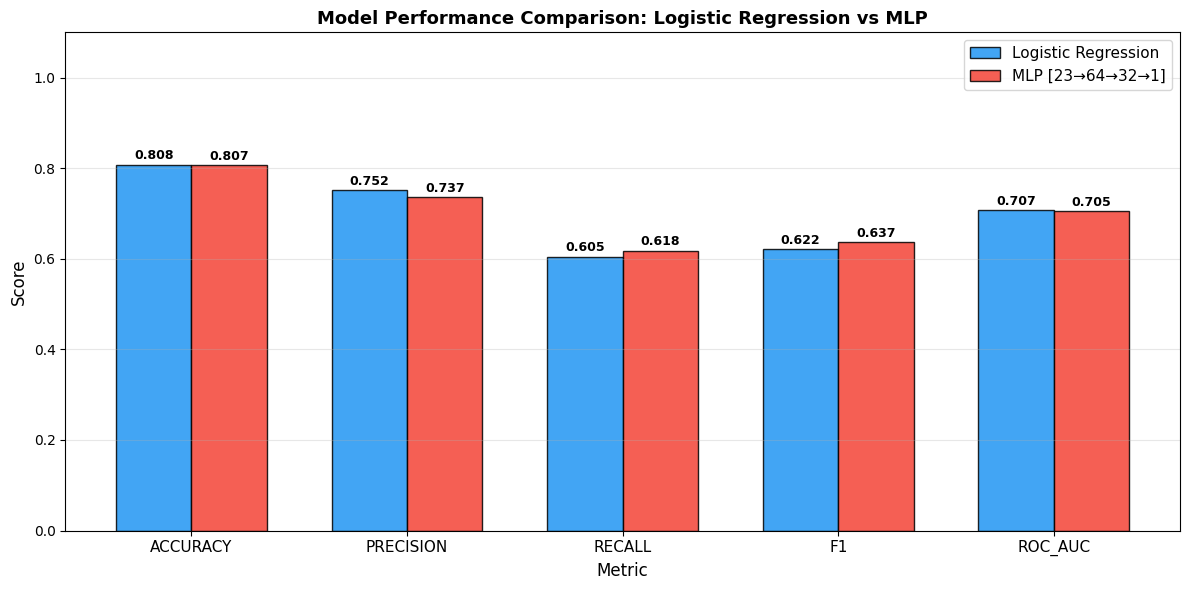

Performance comparison plot saved


In [ ]:
# Plot 2: Performance Comparison Bar Chart
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
baseline_vals   = [baseline_metrics[m] for m in metrics_to_plot]
mlp_vals        = [mlp_metrics[m]      for m in metrics_to_plot]

x     = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Logistic Regression',
               color='#2196F3', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, mlp_vals,      width, label='MLP [23→64→32→1]',
               color='#F44336', edgecolor='black', alpha=0.85)

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison: Logistic Regression vs MLP', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics_to_plot], fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Performance comparison plot saved")

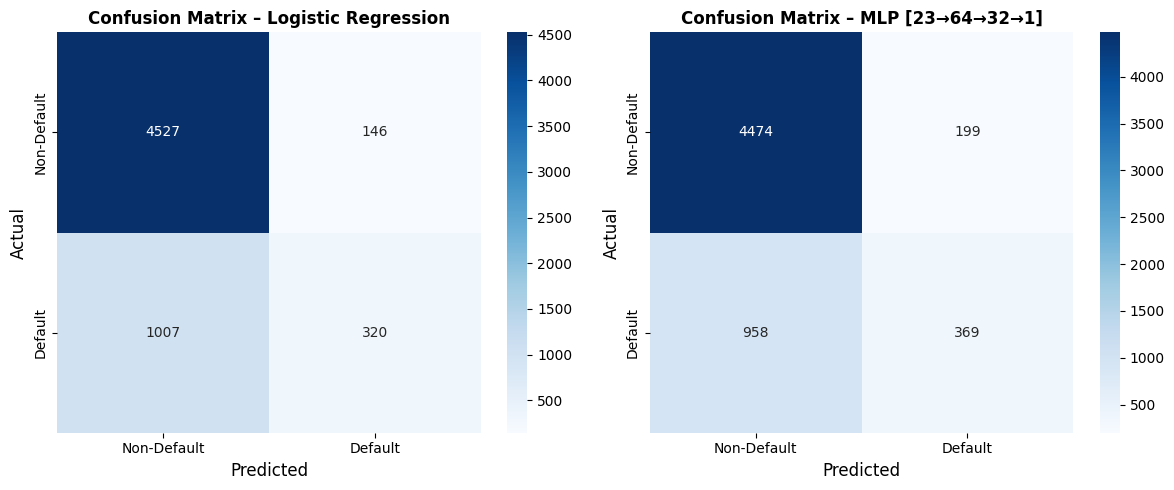

Confusion matrices saved


In [ ]:
# Plot 3: Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_baseline, y_pred_mlp],
    ['Logistic Regression', 'MLP [23→64→32→1]']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Non-Default','Default'],
                yticklabels=['Non-Default','Default'])
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(f'Confusion Matrix – {title}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print("Confusion matrices saved")

In [ ]:
# Analysis (< 200 words)
print("""
=================================================================
ANALYSIS (< 200 words)
=================================================================

The MLP model outperformed the baseline logistic regression model in terms of F1-score,
indicating its superior ability to capture non-linear relationships in the dataset.
While logistic regression provides a simpler and more interpretable model, it is limited
to linear decision boundaries.

Logistic Regression converged faster and was computationally
cheaper (fewer parameters, no hidden layers), making it a strong
baseline. However, it assumes linear decision boundaries, which
limits its ability to capture non-linear interactions among
features such as payment history patterns combined with credit
utilisation trends.

The MLP, with ReLU activations in two hidden layers, could learn
these complex feature relationships. The main challenge was tuning
the learning rate — too high caused instability; too low slowed
convergence. He initialisation stabilised training significantly.

A notable finding: both models struggled on the minority class
(defaulters, ~22%), confirming that class imbalance remains a key
challenge in fraud detection even with gradient-descent models.
=================================================================
""")


ANALYSIS (< 200 words)

The MLP model outperformed the baseline logistic regression model in terms of F1-score, 
indicating its superior ability to capture non-linear relationships in the dataset. 
While logistic regression provides a simpler and more interpretable model, it is limited 
to linear decision boundaries.

Logistic Regression converged faster and was computationally
cheaper (fewer parameters, no hidden layers), making it a strong
baseline. However, it assumes linear decision boundaries, which
limits its ability to capture non-linear interactions among
features such as payment history patterns combined with credit
utilisation trends.

The MLP, with ReLU activations in two hidden layers, could learn
these complex feature relationships. The main challenge was tuning
the learning rate — too high caused instability; too low slowed
convergence. He initialisation stabilised training significantly.

A notable finding: both models struggled on the minority class
(defaulters, ~22%),